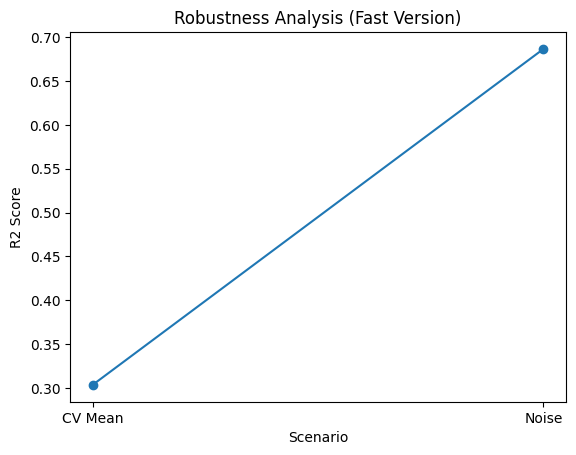

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# ✅ Load dataset (keep your path)
DATA_PATH = "/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv"

df = pd.read_csv(DATA_PATH)

# ✅ SPEED FIX 1: Use smaller sample
df = df.sample(n=3000, random_state=42)

# Basic preprocessing
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

target_col = "Sales" if "Sales" in df.columns else df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

# ✅ SPEED FIX 2: Light model
model = RandomForestRegressor(
    n_estimators=30,      # fewer trees
    max_depth=8,          # limit depth
    n_jobs=-1,            # use all CPU cores
    random_state=42
)

# ✅ SPEED FIX 3: Reduce CV folds
scores = cross_val_score(model, X, y, cv=3, scoring="r2", n_jobs=-1)

# ✅ Noise test (faster)
X_noise = X + np.random.normal(0, 0.05, X.shape)

model.fit(X_noise, y)
pred = model.predict(X_noise)

# Results
df_results = pd.DataFrame({
    "Scenario": ["CV Mean", "Noise"],
    "R2": [scores.mean(), r2_score(y, pred)]
})

df_results.to_csv("RQ6_table.csv", index=False)

# Plot
plt.figure()
plt.plot(df_results["Scenario"], df_results["R2"], marker='o')
plt.title("Robustness Analysis (Fast Version)")
plt.xlabel("Scenario")
plt.ylabel("R2 Score")
plt.savefig("RQ6_figure.pdf")
plt.show()